# Proyecto - Mastering Machine Learning

Descargar y visualizar el dataset

In [1]:
!pip install medmnist
!pip install matplotlib

In [2]:
import os
from medmnist import PneumoniaMNIST

In [4]:
# Directorio actual donde se está ejecutando Jupyter
PROJECT_DIR = os.getcwd()

# Crear /data dentro del proyecto
DATA_DIR = os.path.join(PROJECT_DIR, "data")

# Tamano de las imagenes
IMAGE_SIZE = 28

os.makedirs(DATA_DIR, exist_ok=True)

print("Proyecto:", PROJECT_DIR)
print("Dataset:", DATA_DIR)

Proyecto: /Users/gabrielgomezcorredor/Desktop/Gabriel_Gomez/Maestria MISIS/Mastering ML/proyecto/Mastering_MachineLearning_project
Dataset: /Users/gabrielgomezcorredor/Desktop/Gabriel_Gomez/Maestria MISIS/Mastering ML/proyecto/Mastering_MachineLearning_project/data


In [5]:
# Training data
train_dataset = PneumoniaMNIST(
    split="train",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=True
)

# Validation data
val_dataset = PneumoniaMNIST(
    split="val",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=True
)

# Test data
test_dataset = PneumoniaMNIST(
    split="test",
    root=DATA_DIR,
    size=128,
    download=True
)

100%|██████████| 4.17M/4.17M [00:13<00:00, 314kB/s] 


In [5]:
# --- Cargar las variables ----

import os
from medmnist import PneumoniaMNIST

DATA_DIR = "./data"

train_dataset = PneumoniaMNIST(
    split="train",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=False
)

val_dataset = PneumoniaMNIST(
    split="val",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=False
)

test_dataset = PneumoniaMNIST(
    split="test",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    download=False
)

print("Archivos:", os.listdir(DATA_DIR))

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("Archivos:", os.listdir(DATA_DIR))

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Archivos: ['pneumoniamnist_128.npz', 'pneumoniamnist.npz']
Train: 4708
Validation: 524
Test: 624
Archivos: ['pneumoniamnist_128.npz', 'pneumoniamnist.npz']
Train: 4708
Validation: 524
Test: 624


Visualizar data set

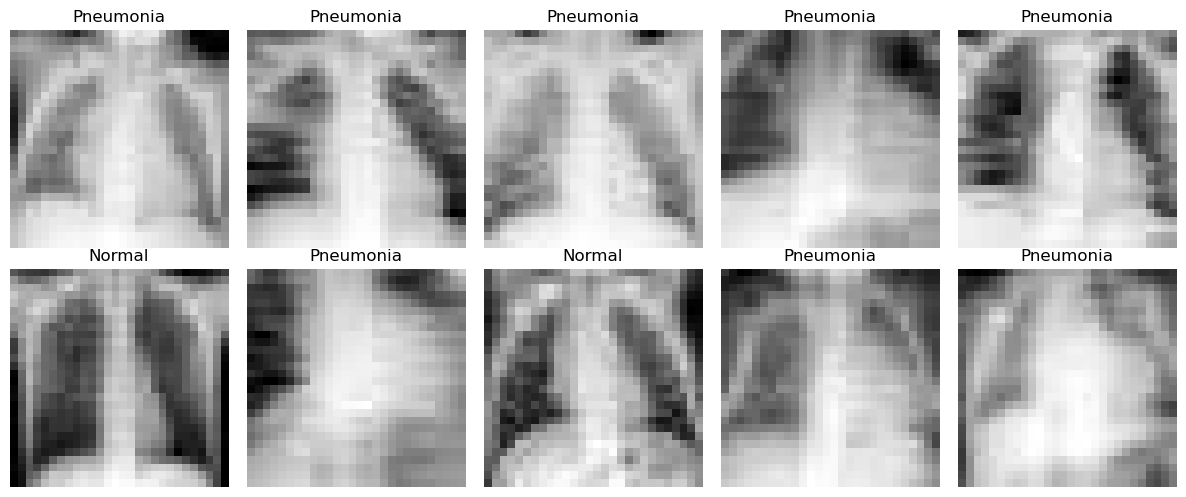

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image, cmap="gray")

    clase = "Normal" if label.item() == 0 else "Pneumonia"
    ax.set_title(clase)

    ax.axis("off")

plt.tight_layout()
plt.show()

Debemos saber si el dataset esta balanceado

In [7]:
import numpy as np

labels = train_dataset.labels.flatten()

clases, cantidades = np.unique(labels, return_counts=True)

for clase, cantidad in zip(clases, cantidades):
    nombre = "Normal" if clase == 0 else "Pneumonia"
    porcentaje = cantidad / len(labels) * 100

    print(f"{nombre}: {cantidad} ({porcentaje:.2f}%)")

Normal: 1214 (25.79%)
Pneumonia: 3494 (74.21%)


## Balancear el conjunto de entrenamiento

Se conservan todas las imágenes normales y se selecciona aleatoriamente la misma cantidad de imágenes con neumonía. La semilla permite reproducir la selección. Este proceso no elimina ni modifica los archivos originales del dataset.

In [8]:
from torch.utils.data import Subset

SEMILLA = 42

# Conservar una referencia al dataset completo, incluso si esta celda se ejecuta otra vez.
if not isinstance(train_dataset, Subset):
    train_dataset_completo = train_dataset

labels_completos = np.asarray(train_dataset_completo.labels).reshape(-1)
indices_normales = np.flatnonzero(labels_completos == 0)
indices_neumonia = np.flatnonzero(labels_completos == 1)

if len(indices_neumonia) < len(indices_normales):
    raise ValueError("No hay suficientes imágenes de neumonía para igualar la clase normal.")

rng = np.random.default_rng(SEMILLA)
indices_neumonia_seleccionados = rng.choice(
    indices_neumonia,
    size=len(indices_normales),
    replace=False
)

indices_balanceados = np.concatenate([
    indices_normales,
    indices_neumonia_seleccionados
])
rng.shuffle(indices_balanceados)

# A partir de aquí, train_dataset es el conjunto balanceado que se debe entrenar.
train_dataset = Subset(train_dataset_completo, indices_balanceados.tolist())

# Verificar el resultado.
labels_balanceados = labels_completos[indices_balanceados]
clases, cantidades = np.unique(labels_balanceados, return_counts=True)

print(f"Total de entrenamiento balanceado: {len(train_dataset)}")
for clase, cantidad in zip(clases, cantidades):
    nombre = "Normal" if clase == 0 else "Pneumonia"
    porcentaje = cantidad / len(labels_balanceados) * 100
    print(f"{nombre}: {cantidad} ({porcentaje:.2f}%)")

Total de entrenamiento balanceado: 2428
Normal: 1214 (50.00%)
Pneumonia: 1214 (50.00%)


# Entrenamiento de las muestras balanceado

Basado en los ejemplos de la librería, vamos a entrenar un modelo que pueda predecir si dada una imagen esta presenta neumonía o no.

Tomado y adaptado de: https://github.com/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb

## Preparar los datos para PyTorch

Las imágenes se convierten a tensores y se normalizan igual que en el ejemplo oficial. El `DataLoader` de entrenamiento usa el subconjunto balanceado creado anteriormente; validación y prueba permanecen completos para medir el rendimiento sobre la distribución original.

In [9]:
import random
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, roc_auc_score

# Hiperparámetros
SEMILLA = 42
NUM_EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 0.001

# Reproducibilidad
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

# Usar GPU cuando esté disponible.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# El Subset balanceado aplica el transform de su dataset base.
train_dataset_completo.transform = data_transform
val_dataset.transform = data_transform
test_dataset.transform = data_transform

generador = torch.Generator().manual_seed(SEMILLA)
usar_pin_memory = DEVICE.type == "cuda"

train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generador,
    num_workers=0,
    pin_memory=usar_pin_memory
)
train_loader_eval = data.DataLoader(
    train_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)
val_loader = data.DataLoader(
    val_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)

print("Dispositivo:", DEVICE)
print("Train balanceado:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Dispositivo: mps
Train balanceado: 2428
Validation: 524
Test: 624


## Definir la red neuronal

Esta CNN sigue la arquitectura del cuaderno oficial para imágenes de 28 × 28. La salida tiene dos valores: clase 0 (`Normal`) y clase 1 (`Pneumonia`).

In [10]:
class PneumoniaCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)


model = PneumoniaCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

PneumoniaCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer5): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, 

## Entrenar el modelo

In [11]:
historial = {"loss": [], "val_loss": [], "acc": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    perdida_acumulada = 0.0
    correctas = 0
    total = 0

    barra = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    for images, targets in barra:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.view(-1).long().to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        cantidad = targets.size(0)
        perdida_acumulada += loss.item() * cantidad
        correctas += (outputs.argmax(dim=1) == targets).sum().item()
        total += cantidad
        barra.set_postfix(loss=f"{perdida_acumulada / total:.4f}")

    epoch_loss = perdida_acumulada / total
    epoch_acc = correctas / total

    # Calcular la pérdida de validación sin actualizar los pesos.
    model.eval()
    perdida_val_acumulada = 0.0
    total_val = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.view(-1).long().to(DEVICE, non_blocking=True)
            outputs = model(images)
            val_loss = criterion(outputs, targets)
            perdida_val_acumulada += val_loss.item() * targets.size(0)
            total_val += targets.size(0)

    epoch_val_loss = perdida_val_acumulada / total_val
    historial["loss"].append(epoch_loss)
    historial["val_loss"].append(epoch_val_loss)
    historial["acc"].append(epoch_acc)
    print(
        f"Epoch {epoch + 1:02d} - train_loss: {epoch_loss:.4f} "
        f"- val_loss: {epoch_val_loss:.4f} - train_acc: {epoch_acc:.4f}"
    )

Epoch 1/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 - train_loss: 0.2669 - val_loss: 19219497963041838858240.0000 - train_acc: 0.8826


Epoch 2/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 02 - train_loss: 0.1305 - val_loss: 0.1372 - train_acc: 0.9498


Epoch 3/30:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch 28 - train_loss: 0.0001 - val_loss: 0.1334 - train_acc: 1.0000


Epoch 29/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 29 - train_loss: 0.0000 - val_loss: 76409091635501735084032.0000 - train_acc: 1.0000


Epoch 30/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 30 - train_loss: 0.0000 - val_loss: 645334469011864276931969024.0000 - train_acc: 1.0000


## Curva de pérdida

La convergencia se observa cuando la pérdida deja de disminuir de forma importante. Si la pérdida de entrenamiento continúa bajando mientras la de validación empieza a subir, es una señal de sobreajuste.

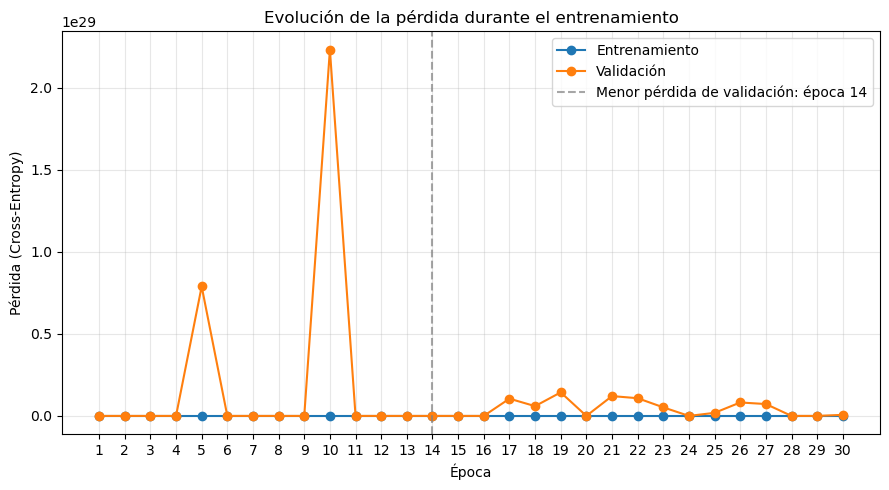

Menor pérdida de validación en la época 14: 0.0857


In [12]:
epocas = np.arange(1, NUM_EPOCHS + 1)
mejor_epoca = int(np.argmin(historial["val_loss"])) + 1

plt.figure(figsize=(9, 5))
plt.plot(epocas, historial["loss"], marker="o", label="Entrenamiento")
plt.plot(epocas, historial["val_loss"], marker="o", label="Validación")
plt.axvline(
    mejor_epoca,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Menor pérdida de validación: época {mejor_epoca}"
)
plt.xlabel("Época")
plt.ylabel("Pérdida (Cross-Entropy)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xticks(epocas)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Menor pérdida de validación en la época {mejor_epoca}: "
    f"{historial['val_loss'][mejor_epoca - 1]:.4f}"
)

## Evaluar AUC y accuracy

`Evaluator` de MedMNIST compara contra el número fijo de ejemplos del conjunto oficial y por eso no acepta directamente el `Subset` balanceado. La siguiente función calcula las mismas métricas usando las etiquetas y predicciones de cada `DataLoader`.

In [13]:
def evaluar_modelo(data_loader):
    model.eval()
    etiquetas = []
    probabilidades = []
    predicciones = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            probs_neumonia = torch.softmax(outputs, dim=1)[:, 1]

            etiquetas.extend(targets.view(-1).cpu().numpy())
            probabilidades.extend(probs_neumonia.cpu().numpy())
            predicciones.extend(outputs.argmax(dim=1).cpu().numpy())

    etiquetas = np.asarray(etiquetas)
    probabilidades = np.asarray(probabilidades)
    predicciones = np.asarray(predicciones)

    auc = roc_auc_score(etiquetas, probabilidades)
    acc = accuracy_score(etiquetas, predicciones)
    return auc, acc


print("==> Evaluating ...")
for nombre, loader in [
    ("train", train_loader_eval),
    ("val", val_loader),
    ("test", test_loader)
]:
    auc, acc = evaluar_modelo(loader)
    print(f"{nombre:<5} auc: {auc:.3f}  acc:{acc:.3f}")

==> Evaluating ...
train auc: 1.000  acc:1.000
val   auc: 0.997  acc:0.969
test  auc: 0.971  acc:0.910


## Matriz de confusión sobre el conjunto de prueba

Las filas representan la clase real y las columnas la clase predicha. La matriz se calcula sobre `test_loader`, que no participó en el entrenamiento.

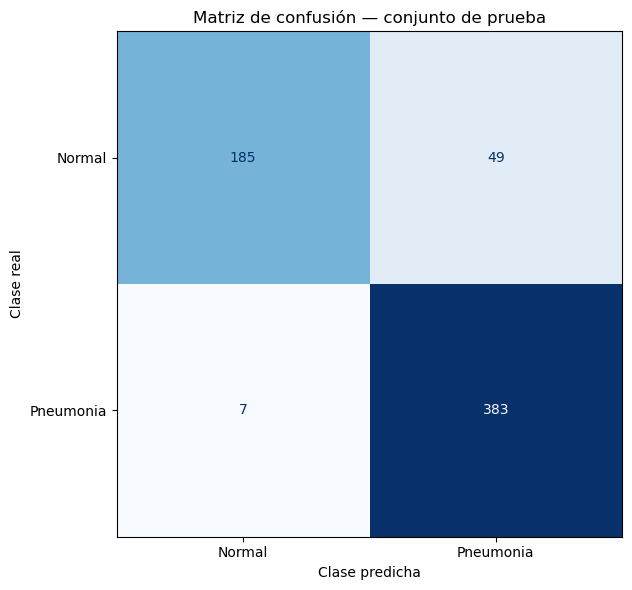

Verdaderos negativos (Normal → Normal): 185
Falsos positivos (Normal → Pneumonia): 49
Falsos negativos (Pneumonia → Normal): 7
Verdaderos positivos (Pneumonia → Pneumonia): 383

==> Métricas del conjunto de prueba
Accuracy:  0.910
Precision: 0.887
Recall:    0.982


In [14]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score
)

model.eval()
etiquetas_test = []
predicciones_test = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predicciones = outputs.argmax(dim=1).cpu().numpy()

        etiquetas_test.extend(targets.view(-1).cpu().numpy())
        predicciones_test.extend(predicciones)

etiquetas_test = np.asarray(etiquetas_test)
predicciones_test = np.asarray(predicciones_test)

matriz = confusion_matrix(
    etiquetas_test,
    predicciones_test,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))
display = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Normal", "Pneumonia"]
)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusión — conjunto de prueba")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = matriz.ravel()
print("Verdaderos negativos (Normal → Normal):", verdaderos_negativos)
print("Falsos positivos (Normal → Pneumonia):", falsos_positivos)
print("Falsos negativos (Pneumonia → Normal):", falsos_negativos)
print("Verdaderos positivos (Pneumonia → Pneumonia):", verdaderos_positivos)

# Pneumonia (clase 1) se considera la clase positiva.
accuracy_test = accuracy_score(etiquetas_test, predicciones_test)
precision_test = precision_score(
    etiquetas_test,
    predicciones_test,
    pos_label=1,
    zero_division=0
)
recall_test = recall_score(
    etiquetas_test,
    predicciones_test,
    pos_label=1,
    zero_division=0
)

print("\n==> Métricas del conjunto de prueba")
print(f"Accuracy:  {accuracy_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall:    {recall_test:.3f}")

## Realizar una predicción individual

In [15]:
def predecir_neumonia(image_tensor):
    """Predice una imagen ya transformada por data_transform."""
    model.eval()
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    with torch.no_grad():
        outputs = model(image_tensor.to(DEVICE))
        probabilidades = torch.softmax(outputs, dim=1)[0]
        clase = probabilidades.argmax().item()

    return {
        "clase": "Pneumonia" if clase == 1 else "Normal",
        "probabilidad_normal": probabilidades[0].item(),
        "probabilidad_neumonia": probabilidades[1].item()
    }


for i in range(10):
    imagen_ejemplo, etiqueta_real = test_dataset[i]
    resultado = predecir_neumonia(imagen_ejemplo)

    print("Etiqueta real:", "Pneumonia" if etiqueta_real.item() == 1 else "Normal")
    print("Predicción:", resultado)

Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 6.494199622508745e-10, 'probabilidad_neumonia': 1.0}
Etiqueta real: Normal
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 1.529284645584994e-06, 'probabilidad_neumonia': 0.9999984502792358}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 3.6203732634021435e-07, 'probabilidad_neumonia': 0.9999996423721313}
Etiqueta real: Normal
Predicción: {'clase': 'Normal', 'probabilidad_normal': 1.0, 'probabilidad_neumonia': 4.552374921473756e-09}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 2.150467581785165e-09, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 6.44899481039296e-11, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 7.810915469974589e-09, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Pr

# Generación de imágenes sintéticas usando Flow Matching

Esta sección adapta el procedimiento de `Taller4_Grupo9.ipynb` a imágenes. Se entrena únicamente con las 1214 radiografías de clase `Normal`. El modelo aprende un campo de velocidades que transporta ruido gaussiano hacia la distribución de radiografías normales de 28 × 28.

## Preparar las imágenes normales

Los píxeles se normalizan al intervalo aproximado [-1, 1], igual que para el clasificador. Se crea un dataset independiente para no modificar los `DataLoader` usados anteriormente.

In [16]:
import math
from pathlib import Path

import torch.nn.functional as F
from torchvision.utils import save_image

FLOW_SEED = 42
FLOW_IMAGE_SIZE = 28
FLOW_BATCH_SIZE = 64
FLOW_EPOCHS = 50
FLOW_LEARNING_RATE = 2e-4

random.seed(FLOW_SEED)
np.random.seed(FLOW_SEED)
torch.manual_seed(FLOW_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(FLOW_SEED)

if torch.cuda.is_available():
    FLOW_DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    FLOW_DEVICE = torch.device("mps")
else:
    FLOW_DEVICE = torch.device("cpu")

flow_transform = transforms.Compose([
    transforms.Resize((FLOW_IMAGE_SIZE, FLOW_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Se vuelve a abrir el mismo split de entrenamiento con el transform del generador.
flow_train_dataset = PneumoniaMNIST(
    split="train",
    root=DATA_DIR,
    size=IMAGE_SIZE,
    transform=flow_transform,
    download=False
)

flow_labels = np.asarray(flow_train_dataset.labels).reshape(-1)
flow_normal_indices = np.flatnonzero(flow_labels == 0)
flow_normal_dataset = Subset(flow_train_dataset, flow_normal_indices.tolist())

flow_generator = torch.Generator().manual_seed(FLOW_SEED)
flow_loader = data.DataLoader(
    flow_normal_dataset,
    batch_size=FLOW_BATCH_SIZE,
    shuffle=True,
    generator=flow_generator,
    num_workers=0,
    pin_memory=FLOW_DEVICE.type == "cuda",
    drop_last=True
)

flow_images_example, flow_labels_example = next(iter(flow_loader))
assert flow_images_example.shape[1:] == (1, 28, 28)
assert torch.all(flow_labels_example == 0)

print("Dispositivo para Flow Matching:", FLOW_DEVICE)
print("Imágenes normales para entrenamiento:", len(flow_normal_dataset))
print("Forma de un batch:", tuple(flow_images_example.shape))

Dispositivo para Flow Matching: mps
Imágenes normales para entrenamiento: 1214
Forma de un batch: (64, 1, 28, 28)


## Red convolucional de velocidad

La MLP del taller recibe puntos 2D. Para radiografías se reemplaza por una red convolucional tipo U-Net. La red recibe una imagen interpolada `x_t` y el tiempo `t`, y devuelve una velocidad con la misma forma `[batch, 1, 28, 28]`.

In [17]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

    def forward(self, t):
        half_dim = self.embedding_dim // 2
        frequencies = torch.exp(
            -math.log(10_000) * torch.arange(
                half_dim,
                device=t.device,
                dtype=t.dtype
            ) / (half_dim - 1)
        )
        angles = (1_000 * t[:, None]) * frequencies[None, :]
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)


class TimeResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim=128):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.time_projection = nn.Linear(time_dim, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )

    def forward(self, x, time_embedding):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_projection(time_embedding)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class ImageVelocityUNet(nn.Module):
    def __init__(self, base_channels=32, time_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.input_conv = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)
        self.encoder1 = TimeResidualBlock(base_channels, base_channels, time_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, 4, stride=2, padding=1)
        self.encoder2 = TimeResidualBlock(base_channels * 2, base_channels * 2, time_dim)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, 4, stride=2, padding=1)

        self.bottleneck1 = TimeResidualBlock(base_channels * 4, base_channels * 4, time_dim)
        self.bottleneck2 = TimeResidualBlock(base_channels * 4, base_channels * 4, time_dim)

        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, stride=2, padding=1)
        self.decoder1 = TimeResidualBlock(base_channels * 4, base_channels * 2, time_dim)
        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, 4, stride=2, padding=1)
        self.decoder2 = TimeResidualBlock(base_channels * 2, base_channels, time_dim)

        self.output_norm = nn.GroupNorm(8, base_channels)
        self.output_conv = nn.Conv2d(base_channels, 1, kernel_size=3, padding=1)

    def forward(self, xt, t):
        if t.ndim == 0:
            t = t.expand(xt.size(0))
        time_embedding = self.time_embedding(t)

        x0 = self.input_conv(xt)
        x1 = self.encoder1(x0, time_embedding)
        x2 = self.encoder2(self.down1(x1), time_embedding)
        x3 = self.bottleneck1(self.down2(x2), time_embedding)
        x3 = self.bottleneck2(x3, time_embedding)

        y2 = self.up1(x3)
        y2 = self.decoder1(torch.cat([y2, x2], dim=1), time_embedding)
        y1 = self.up2(y2)
        y1 = self.decoder2(torch.cat([y1, x1], dim=1), time_embedding)

        return self.output_conv(F.silu(self.output_norm(y1)))

## Modelo de Flow Matching para imágenes

Al igual que en el taller, se usa el interpolante `x_t = (1-t)x_0 + tx_1`. Su derivada es la velocidad objetivo `x_1-x_0`. La generación integra la ODE aprendida desde `t=0` hasta `t=1` con el método de Heun.

In [19]:
class ImageFlowMatching(nn.Module):
    def __init__(self, velocity_network, device):
        super().__init__()
        self.velocity_network = velocity_network
        self.device = device

    def sample_time(self, batch_size):
        return torch.rand(batch_size, device=self.device)

    @staticmethod
    def interpolate(x0, x1, t):
        t_image = t.view(-1, 1, 1, 1)
        return (1 - t_image) * x0 + t_image * x1

    @staticmethod
    def target_velocity(x0, x1):
        return x1 - x0

    def compute_loss(self, x1):
        x0 = torch.randn_like(x1)
        t = self.sample_time(x1.size(0))
        xt = self.interpolate(x0, x1, t)
        predicted_velocity = self.velocity_network(xt, t)
        velocity_target = self.target_velocity(x0, x1)
        return F.mse_loss(predicted_velocity, velocity_target)

    @torch.no_grad()
    def sample(self, num_samples=16, num_steps=100):
        was_training = self.training
        self.eval()

        x = torch.randn(
            num_samples,
            1,
            FLOW_IMAGE_SIZE,
            FLOW_IMAGE_SIZE,
            device=self.device
        )
        dt = 1.0 / num_steps

        # Integración de Heun: predictor de Euler y corrección trapezoidal.
        for step in range(num_steps):
            t_value = step * dt
            t = torch.full((num_samples,), t_value, device=self.device)
            velocity = self.velocity_network(x, t)
            x_euler = x + dt * velocity

            t_next = torch.full(
                (num_samples,),
                min(t_value + dt, 1.0),
                device=self.device
            )
            velocity_next = self.velocity_network(x_euler, t_next)
            x = x + 0.5 * dt * (velocity + velocity_next)

        if was_training:
            self.train()
        return x.clamp(-1, 1)


flow_velocity_network = ImageVelocityUNet().to(FLOW_DEVICE)
flow_model = ImageFlowMatching(flow_velocity_network, FLOW_DEVICE).to(FLOW_DEVICE)

# Prueba de dimensiones antes de entrenar.
flow_test_batch = flow_images_example[:4].to(FLOW_DEVICE)
flow_test_time = torch.rand(flow_test_batch.size(0), device=FLOW_DEVICE)
with torch.no_grad():
    flow_test_output = flow_velocity_network(flow_test_batch, flow_test_time)

assert flow_test_output.shape == flow_test_batch.shape
print("Salida de la red de velocidad:", tuple(flow_test_output.shape))
print("Pérdida inicial:", flow_model.compute_loss(flow_test_batch).item())

Salida de la red de velocidad: (4, 1, 28, 28)
Pérdida inicial: 1.2454158067703247


## Entrenar el Flow Matching

La pérdida MSE compara la velocidad predicha con `x_1-x_0`. En CPU puede ser conveniente reducir temporalmente `FLOW_EPOCHS`; para obtener mejores imágenes se recomienda entrenar las 50 épocas con GPU.

In [20]:
flow_optimizer = optim.AdamW(
    flow_model.parameters(),
    lr=FLOW_LEARNING_RATE,
    weight_decay=1e-4
)
flow_losses = []

for epoch in range(FLOW_EPOCHS):
    flow_model.train()
    accumulated_loss = 0.0
    examples_seen = 0

    progress = tqdm(flow_loader, desc=f"Flow epoch {epoch + 1}/{FLOW_EPOCHS}")
    for images, _ in progress:
        images = images.to(FLOW_DEVICE, non_blocking=True)

        flow_optimizer.zero_grad()
        loss = flow_model.compute_loss(images)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)
        flow_optimizer.step()

        accumulated_loss += loss.item() * images.size(0)
        examples_seen += images.size(0)
        progress.set_postfix(loss=f"{accumulated_loss / examples_seen:.4f}")

    epoch_loss = accumulated_loss / examples_seen
    flow_losses.append(epoch_loss)
    print(f"Flow epoch {epoch + 1:03d} - loss: {epoch_loss:.5f}")

FLOW_CHECKPOINT = "flow_matching_normal_28x28.pt"
torch.save(
    {
        "model_state_dict": flow_model.state_dict(),
        "image_size": FLOW_IMAGE_SIZE,
        "epochs": FLOW_EPOCHS,
        "losses": flow_losses
    },
    FLOW_CHECKPOINT
)
print("Modelo guardado en:", FLOW_CHECKPOINT)

Flow epoch 1/50:   0%|          | 0/18 [00:00<?, ?it/s]

Flow epoch 001 - loss: 0.68457


Flow epoch 2/50:   0%|          | 0/18 [00:00<?, ?it/s]

Flow epoch 002 - loss: 0.34815


Flow epoch 3/50:   0%|          | 0/18 [00:00<?, ?it/s]

...

Flow epoch 048 - loss: 0.15710


Flow epoch 49/50:   0%|          | 0/18 [00:00<?, ?it/s]

Flow epoch 049 - loss: 0.15958


Flow epoch 50/50:   0%|          | 0/18 [00:00<?, ?it/s]

Flow epoch 050 - loss: 0.15571
Modelo guardado en: flow_matching_normal_28x28.pt


## Pérdida del modelo generativo

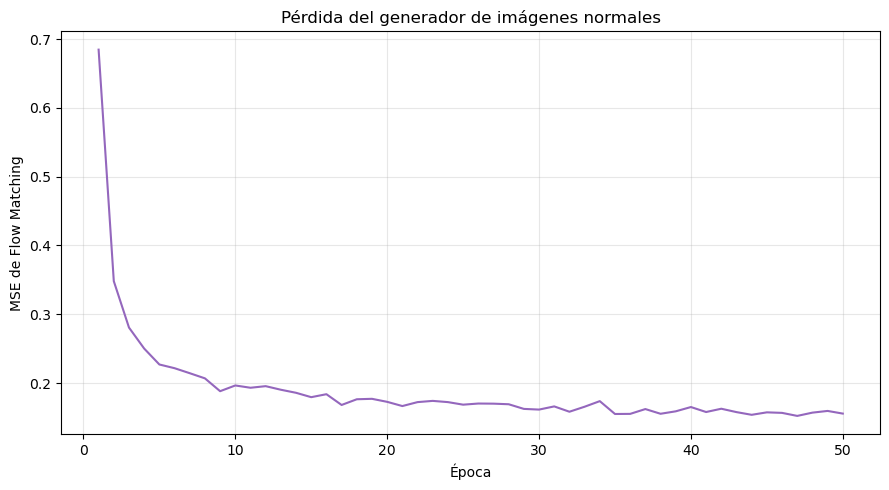

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(1, len(flow_losses) + 1),
    flow_losses,
    color="tab:purple"
)
plt.xlabel("Época")
plt.ylabel("MSE de Flow Matching")
plt.title("Pérdida del generador de imágenes normales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Generar y guardar radiografías sintéticas normales

Las imágenes se generan desde ruido nuevo, se convierten de [-1, 1] a [0, 1] y se guardan individualmente como PNG de 28 × 28.

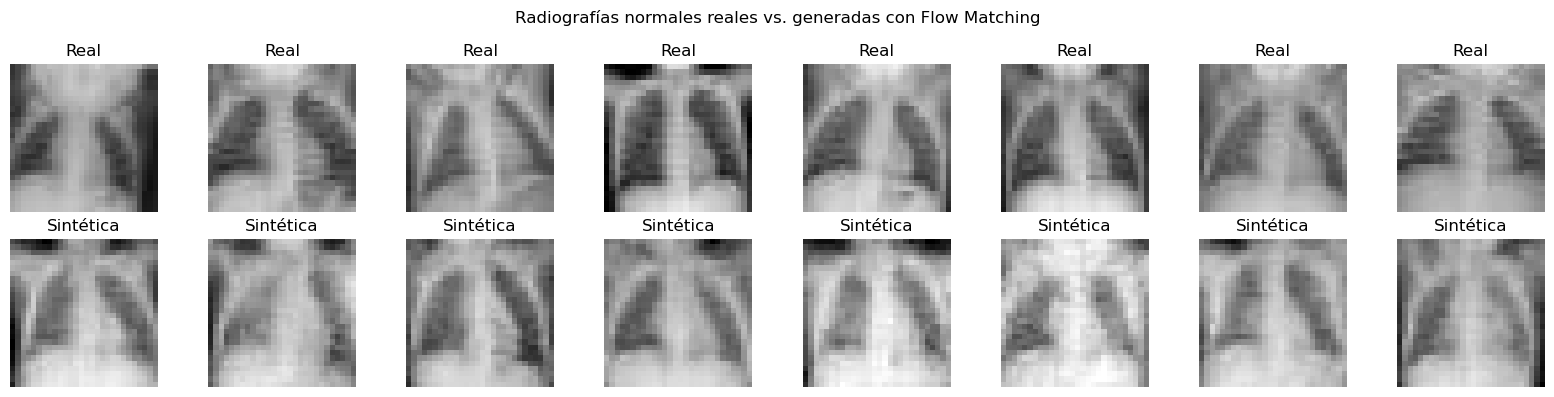

Se guardaron 607 imágenes en: /Users/gabrielgomezcorredor/Desktop/Gabriel_Gomez/Maestria MISIS/Mastering ML/proyecto/Mastering_MachineLearning_project/synthetic_normal_28x28
Forma del tensor generado: (607, 1, 28, 28)


In [22]:
NUM_SYNTHETIC_NORMAL = 607 # Mitad de las 1214 normales
FLOW_SAMPLING_STEPS = 100

synthetic_normal_normalized = flow_model.sample(
    num_samples=NUM_SYNTHETIC_NORMAL,
    num_steps=FLOW_SAMPLING_STEPS
).cpu()
synthetic_normal_images = (synthetic_normal_normalized + 1) / 2
synthetic_normal_images = synthetic_normal_images.clamp(0, 1)

# Comparar ejemplos reales y sintéticos.
real_normal_images = (flow_images_example[:8] + 1) / 2
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for index in range(8):
    axes[0, index].imshow(real_normal_images[index, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, index].set_title("Real")
    axes[0, index].axis("off")

    axes[1, index].imshow(synthetic_normal_images[index, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, index].set_title("Sintética")
    axes[1, index].axis("off")

plt.suptitle("Radiografías normales reales vs. generadas con Flow Matching")
plt.tight_layout()
plt.show()

synthetic_output_dir = Path("synthetic_normal_28x28")
synthetic_output_dir.mkdir(parents=True, exist_ok=True)

for index, image in enumerate(synthetic_normal_images):
    image_path = synthetic_output_dir / f"normal_synthetic_{index:04d}.png"
    save_image(image, image_path)

print(f"Se guardaron {NUM_SYNTHETIC_NORMAL} imágenes en: {synthetic_output_dir.resolve()}")
print("Forma del tensor generado:", tuple(synthetic_normal_images.shape))

## Al tener un dataset de normales: 607 imagenes reales y 607 sinteticas, volvemos a entrenar el clasificador.

1. De las imagenes reales normales: Reemplazar 607 por las generadas con flow matching 

In [28]:
from pathlib import Path
from PIL import Image

import numpy as np
from torch.utils.data import Dataset, Subset, ConcatDataset


SEMILLA = 42
NUM_NORMAL_REALES = 607
NUM_NORMAL_SINTETICAS = 607
NUM_PNEUMONIA = 1214

SYNTHETIC_DIR = "./synthetic_normal_28x28"


# ---------------------------------------------------------
# 1. Obtener labels del dataset ORIGINAL
# ---------------------------------------------------------

labels_completos = np.asarray(
    train_dataset_completo.labels
).reshape(-1)

indices_normales = np.flatnonzero(labels_completos == 0)
indices_neumonia = np.flatnonzero(labels_completos == 1)

print("NORMAL disponibles:", len(indices_normales))
print("PNEUMONIA disponibles:", len(indices_neumonia))


# ---------------------------------------------------------
# 2. Seleccionar 607 NORMAL reales
# ---------------------------------------------------------

rng = np.random.default_rng(SEMILLA)

indices_normales_seleccionados = rng.choice(
    indices_normales,
    size=NUM_NORMAL_REALES,
    replace=False
)

normal_real_dataset = Subset(
    train_dataset_completo,
    indices_normales_seleccionados.tolist()
)


# ---------------------------------------------------------
# 3. Seleccionar 1214 PNEUMONIA reales
# ---------------------------------------------------------

indices_neumonia_seleccionados = rng.choice(
    indices_neumonia,
    size=NUM_PNEUMONIA,
    replace=False
)

pneumonia_real_dataset = Subset(
    train_dataset_completo,
    indices_neumonia_seleccionados.tolist()
)


# ---------------------------------------------------------
# 4. Dataset de imágenes NORMAL sintéticas
# ---------------------------------------------------------

class SyntheticNormalDataset(Dataset):

    def __init__(self, folder, transform=None):
        self.image_paths = sorted(
            Path(folder).glob("*.png")
        )

        self.transform = transform

        if len(self.image_paths) == 0:
            raise ValueError(
                f"No se encontraron imágenes PNG en {folder}"
            )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image = Image.open(
            self.image_paths[index]
        ).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        # Mismo formato de label que PneumoniaMNIST
        label = np.array([0], dtype=np.int64)

        return image, label


synthetic_normal_dataset = SyntheticNormalDataset(
    SYNTHETIC_DIR
)


# ---------------------------------------------------------
# 5. Verificar cantidad de imágenes sintéticas
# ---------------------------------------------------------

if len(synthetic_normal_dataset) != NUM_NORMAL_SINTETICAS:
    raise ValueError(
        f"Se esperaban {NUM_NORMAL_SINTETICAS} imágenes sintéticas, "
        f"pero se encontraron {len(synthetic_normal_dataset)}."
    )


# ---------------------------------------------------------
# 6. Crear nuevo dataset de entrenamiento
# ---------------------------------------------------------

train_dataset = ConcatDataset([
    normal_real_dataset,       # 607 NORMAL reales
    synthetic_normal_dataset,  # 607 NORMAL sintéticas
    pneumonia_real_dataset     # 1214 PNEUMONIA reales
])


# ---------------------------------------------------------
# 7. Verificación
# ---------------------------------------------------------

normal_total = (
    len(normal_real_dataset)
    + len(synthetic_normal_dataset)
)

pneumonia_total = len(pneumonia_real_dataset)

print("\n--- NUEVO DATASET DE ENTRENAMIENTO ---")
print(f"NORMAL reales:      {len(normal_real_dataset)}")
print(f"NORMAL sintéticas:  {len(synthetic_normal_dataset)}")
print(f"NORMAL total:       {normal_total}")
print(f"PNEUMONIA reales:   {pneumonia_total}")
print("--------------------------------------")
print(f"TOTAL:              {len(train_dataset)}")

print(
    f"\nNORMAL:    {normal_total / len(train_dataset) * 100:.2f}%"
)
print(
    f"PNEUMONIA: {pneumonia_total / len(train_dataset) * 100:.2f}%"
)

NORMAL disponibles: 1214
PNEUMONIA disponibles: 3494

--- NUEVO DATASET DE ENTRENAMIENTO ---
NORMAL reales:      607
NORMAL sintéticas:  607
NORMAL total:       1214
PNEUMONIA reales:   1214
--------------------------------------
TOTAL:              2428

NORMAL:    50.00%
PNEUMONIA: 50.00%


## Debemos cargar los dataloaders, nueva CNN y entrenar

Transformaciones

In [29]:
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Dataset real base.
# Los Subset normal_real_dataset y pneumonia_real_dataset
# utilizan este mismo dataset internamente.
train_dataset_completo.transform = data_transform

# Dataset sintético.
synthetic_normal_dataset.transform = data_transform

# Validation y Test siguen siendo 100% reales.
val_dataset.transform = data_transform
test_dataset.transform = data_transform

Ajustamos los data loaders

In [30]:
BATCH_SIZE = 128

generador = torch.Generator().manual_seed(SEMILLA)
usar_pin_memory = DEVICE.type == "cuda"

train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generador,
    num_workers=0,
    pin_memory=usar_pin_memory
)

val_loader = data.DataLoader(
    val_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)

test_loader = data.DataLoader(
    test_dataset,
    batch_size=2 * BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=usar_pin_memory
)

In [31]:
images, labels = next(iter(train_loader))

print("Shape imágenes:", images.shape)
print("Shape labels:", labels.shape)

print("NORMAL en batch:", (labels == 0).sum().item())
print("PNEUMONIA en batch:", (labels == 1).sum().item())

print("Min:", images.min().item())
print("Max:", images.max().item())

Shape imágenes: torch.Size([128, 1, 28, 28])
Shape labels: torch.Size([128, 1])
NORMAL en batch: 64
PNEUMONIA en batch: 64
Min: -1.0
Max: 1.0


## Nueva CNN

In [32]:
LEARNING_RATE = 0.001

model = PneumoniaCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

PneumoniaCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer5): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, 

## Entrenar modelo

In [33]:
historial = {"loss": [], "val_loss": [], "acc": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    perdida_acumulada = 0.0
    correctas = 0
    total = 0

    barra = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    for images, targets in barra:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.view(-1).long().to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        cantidad = targets.size(0)
        perdida_acumulada += loss.item() * cantidad
        correctas += (outputs.argmax(dim=1) == targets).sum().item()
        total += cantidad
        barra.set_postfix(loss=f"{perdida_acumulada / total:.4f}")

    epoch_loss = perdida_acumulada / total
    epoch_acc = correctas / total

    # Calcular la pérdida de validación sin actualizar los pesos.
    model.eval()
    perdida_val_acumulada = 0.0
    total_val = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.view(-1).long().to(DEVICE, non_blocking=True)
            outputs = model(images)
            val_loss = criterion(outputs, targets)
            perdida_val_acumulada += val_loss.item() * targets.size(0)
            total_val += targets.size(0)

    epoch_val_loss = perdida_val_acumulada / total_val
    historial["loss"].append(epoch_loss)
    historial["val_loss"].append(epoch_val_loss)
    historial["acc"].append(epoch_acc)
    print(
        f"Epoch {epoch + 1:02d} - train_loss: {epoch_loss:.4f} "
        f"- val_loss: {epoch_val_loss:.4f} - train_acc: {epoch_acc:.4f}"
    )

Epoch 1/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 - train_loss: 0.2539 - val_loss: 1.4207 - train_acc: 0.8834


Epoch 2/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 02 - train_loss: 0.1093 - val_loss: 0.8816 - train_acc: 0.9621


Epoch 3/30:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch 28 - train_loss: 0.0000 - val_loss: 17995776575161069848282730967597056.0000 - train_acc: 1.0000


Epoch 29/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 29 - train_loss: 0.0000 - val_loss: 0.1299 - train_acc: 1.0000


Epoch 30/30:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 30 - train_loss: 0.0000 - val_loss: 0.1848 - train_acc: 1.0000


## Curva de perdida

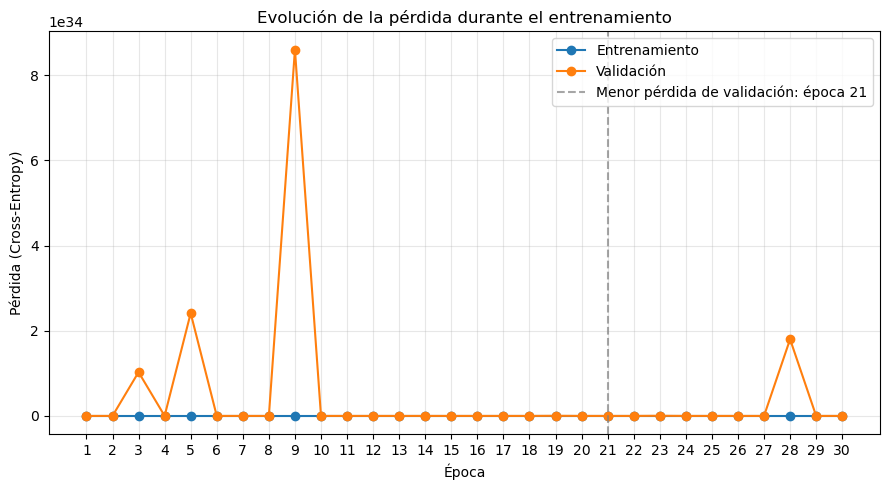

Menor pérdida de validación en la época 21: 0.0980


In [34]:
epocas = np.arange(1, NUM_EPOCHS + 1)
mejor_epoca = int(np.argmin(historial["val_loss"])) + 1

plt.figure(figsize=(9, 5))
plt.plot(epocas, historial["loss"], marker="o", label="Entrenamiento")
plt.plot(epocas, historial["val_loss"], marker="o", label="Validación")
plt.axvline(
    mejor_epoca,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Menor pérdida de validación: época {mejor_epoca}"
)
plt.xlabel("Época")
plt.ylabel("Pérdida (Cross-Entropy)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xticks(epocas)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Menor pérdida de validación en la época {mejor_epoca}: "
    f"{historial['val_loss'][mejor_epoca - 1]:.4f}"
)

## Evaluar AUC y Accuracy

In [35]:
def evaluar_modelo(data_loader):
    model.eval()
    etiquetas = []
    probabilidades = []
    predicciones = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            probs_neumonia = torch.softmax(outputs, dim=1)[:, 1]

            etiquetas.extend(targets.view(-1).cpu().numpy())
            probabilidades.extend(probs_neumonia.cpu().numpy())
            predicciones.extend(outputs.argmax(dim=1).cpu().numpy())

    etiquetas = np.asarray(etiquetas)
    probabilidades = np.asarray(probabilidades)
    predicciones = np.asarray(predicciones)

    auc = roc_auc_score(etiquetas, probabilidades)
    acc = accuracy_score(etiquetas, predicciones)
    return auc, acc


print("==> Evaluating ...")
for nombre, loader in [
    ("train", train_loader_eval),
    ("val", val_loader),
    ("test", test_loader)
]:
    auc, acc = evaluar_modelo(loader)
    print(f"{nombre:<5} auc: {auc:.3f}  acc:{acc:.3f}")

==> Evaluating ...
train auc: 0.998  acc:0.982
val   auc: 0.996  acc:0.977
test  auc: 0.954  acc:0.864


## Matriz de confusión

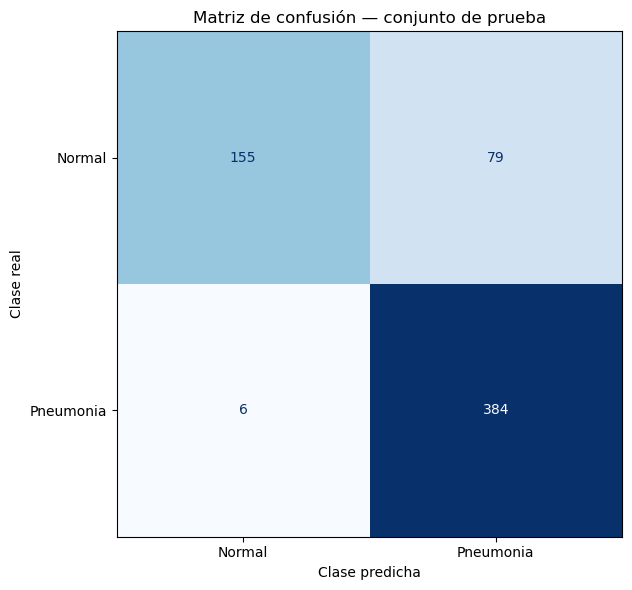

Verdaderos negativos (Normal → Normal): 155
Falsos positivos (Normal → Pneumonia): 79
Falsos negativos (Pneumonia → Normal): 6
Verdaderos positivos (Pneumonia → Pneumonia): 384

==> Métricas del conjunto de prueba
Accuracy:  0.864
Precision: 0.829
Recall:    0.985


In [36]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score
)

model.eval()
etiquetas_test = []
predicciones_test = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predicciones = outputs.argmax(dim=1).cpu().numpy()

        etiquetas_test.extend(targets.view(-1).cpu().numpy())
        predicciones_test.extend(predicciones)

etiquetas_test = np.asarray(etiquetas_test)
predicciones_test = np.asarray(predicciones_test)

matriz = confusion_matrix(
    etiquetas_test,
    predicciones_test,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))
display = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Normal", "Pneumonia"]
)
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusión — conjunto de prueba")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = matriz.ravel()
print("Verdaderos negativos (Normal → Normal):", verdaderos_negativos)
print("Falsos positivos (Normal → Pneumonia):", falsos_positivos)
print("Falsos negativos (Pneumonia → Normal):", falsos_negativos)
print("Verdaderos positivos (Pneumonia → Pneumonia):", verdaderos_positivos)

# Pneumonia (clase 1) se considera la clase positiva.
accuracy_test = accuracy_score(etiquetas_test, predicciones_test)
precision_test = precision_score(
    etiquetas_test,
    predicciones_test,
    pos_label=1,
    zero_division=0
)
recall_test = recall_score(
    etiquetas_test,
    predicciones_test,
    pos_label=1,
    zero_division=0
)

print("\n==> Métricas del conjunto de prueba")
print(f"Accuracy:  {accuracy_test:.3f}")
print(f"Precision: {precision_test:.3f}")
print(f"Recall:    {recall_test:.3f}")

## Realizar una prediccion individual

In [37]:
def predecir_neumonia(image_tensor):
    """Predice una imagen ya transformada por data_transform."""
    model.eval()
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    with torch.no_grad():
        outputs = model(image_tensor.to(DEVICE))
        probabilidades = torch.softmax(outputs, dim=1)[0]
        clase = probabilidades.argmax().item()

    return {
        "clase": "Pneumonia" if clase == 1 else "Normal",
        "probabilidad_normal": probabilidades[0].item(),
        "probabilidad_neumonia": probabilidades[1].item()
    }


for i in range(10):
    imagen_ejemplo, etiqueta_real = test_dataset[i]
    resultado = predecir_neumonia(imagen_ejemplo)

    print("Etiqueta real:", "Pneumonia" if etiqueta_real.item() == 1 else "Normal")
    print("Predicción:", resultado)

Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 3.055167496768263e-08, 'probabilidad_neumonia': 1.0}
Etiqueta real: Normal
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 4.993833044864004e-07, 'probabilidad_neumonia': 0.9999995231628418}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 1.4685259884572588e-05, 'probabilidad_neumonia': 0.9999853372573853}
Etiqueta real: Normal
Predicción: {'clase': 'Normal', 'probabilidad_normal': 0.9999996423721313, 'probabilidad_neumonia': 3.2112069447975955e-07}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 1.4702387085563373e-09, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 1.8385706845869265e-10, 'probabilidad_neumonia': 1.0}
Etiqueta real: Pneumonia
Predicción: {'clase': 'Pneumonia', 'probabilidad_normal': 1.2521108772034495e-07, 'probabilidad_neumonia': 0.9999998807